# Particle Filter Localization


## Algorithm Overview

| Step | Name | What happens |
|------|------|--------------|
| 1 | **Initialize** | Scatter $N$ particles uniformly over the grid; all weights $= 1/N$ |
| 2 | **Predict** | Move each particle by the robot's motion + random noise |
| 3 | **Update** | Re-weight each particle: high weight if it is close to the sensor reading |
| 4 | **Resample** | Draw $N$ new particles from the weighted distribution |


---

# Simple Particle Filter Localization with Front-Wall Measurement

This notebook explains a very simple particle filter for 2D robot localization in 10x6 map

We assume that we have a sensor with give us one simple feature:

"There is a wall in front of the robot at distance `z_front`."


The robot state is:

$$
x = [x, y, \theta]
$$

where:

- $x$ is the robot position in the horizontal direction
- $y$ is the robot position in the vertical direction
- $\theta$ is the robot orientation

First we define some helper functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# defind the map
room_width = 10.0
room_height = 6.0

# wrap orientation from [0, 2*pi] to [-pi, pi]
def wrap_angle(angle):
    """
    Wrap angle to the range [-pi, pi].
    """
    return (angle + np.pi) % (2 * np.pi) - np.pi

# function which calculate to predict distance from a robot with a given pose to the wall infront of it
def distance_to_front_wall(pose):
    """
    Predict the distance from a robot pose to the wall in front.

    pose = [x, y, theta]
    """
    x, y, theta = pose

    dx = np.cos(theta)
    dy = np.sin(theta)

    candidates = []

    # Intersection with vertical walls: x = 0 and x = room_width
    if abs(dx) > 1e-9:

        # Left wall: x = 0
        t = (0.0 - x) / dx
        y_hit = y + t * dy

        if t > 0 and 0.0 <= y_hit <= room_height:
            candidates.append(t)

        # Right wall: x = room_width
        t = (room_width - x) / dx
        y_hit = y + t * dy

        if t > 0 and 0.0 <= y_hit <= room_height:
            candidates.append(t)

    # Intersection with horizontal walls: y = 0 and y = room_height
    if abs(dy) > 1e-9:

        # Bottom wall: y = 0
        t = (0.0 - y) / dy
        x_hit = x + t * dx

        if t > 0 and 0.0 <= x_hit <= room_width:
            candidates.append(t)

        # Top wall: y = room_height
        t = (room_height - y) / dy
        x_hit = x + t * dx

        if t > 0 and 0.0 <= x_hit <= room_width:
            candidates.append(t)

    if len(candidates) == 0:
        return np.inf

    return min(candidates)

# Function to plot the map 
def plot_room():
    """
    Plot the rectangular room.
    """
    xs = [0, room_width, room_width, 0, 0]
    ys = [0, 0, room_height, room_height, 0]

    plt.plot(xs, ys, "k-", linewidth=2)

    plt.axis("equal")
    plt.xlim(-0.5, room_width + 0.5)
    plt.ylim(-0.5, room_height + 0.5)
    plt.grid(True)

    plt.xlabel("x [m]")
    plt.ylabel("y [m]")

# Function to plot map with particles
def plot_particles(particles, weights, title="Particle Filter"):
    """
    Plot particles, particle directions, and particle weights.

    Particle weight is shown by:
    - color
    - marker size
    """
    plt.figure(figsize=(8, 5))

    plot_room()

    # Normalize weights for plotting marker sizes
    w_min = np.min(weights)
    w_max = np.max(weights)

    if w_max > w_min:
        weights_normalized = (weights - w_min) / (w_max - w_min)
    else:
        weights_normalized = np.ones_like(weights)

    marker_sizes = 10 + 120 * weights_normalized

    # Plot particles with color representing weight
    scatter = plt.scatter(
        particles[:, 0],
        particles[:, 1],
        s=marker_sizes,
        c=weights,
        alpha=0.7,
        label="Particles"
    )

    plt.colorbar(scatter, label="Particle weight")

    # Plot direction arrows
    arrow_length = 0.35

    plt.quiver(
        particles[:, 0],
        particles[:, 1],
        arrow_length * np.cos(particles[:, 2]),
        arrow_length * np.sin(particles[:, 2]),
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.003,
        alpha=0.4,
        label="Particle directions"
    )


    plt.title(title)
    plt.legend()
    plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


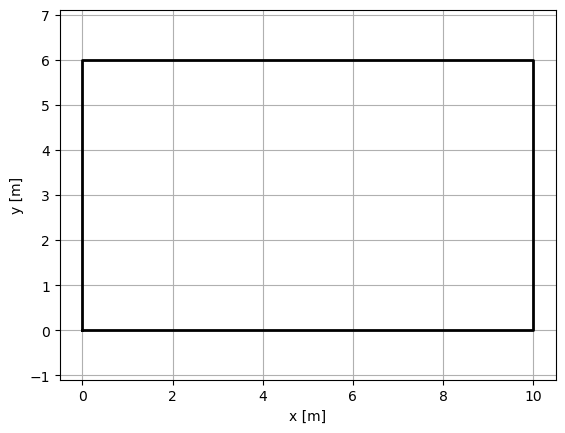

In [2]:
plot_room()
plt.show

In [3]:
test_pose = np.array([3.0, 2.0, 0.0])

distance = distance_to_front_wall(test_pose)

print("Predicted front-wall distance:", distance)

Predicted front-wall distance: 7.0


## Initialize particles

Each particle is one possible robot pose:

$$
p_i = [x_i, y_i, \theta_i]
$$

For this simple example, assume we have no information about the initial pose of the robot, we initialize particles randomly inside the room using uniform distribution np.random.uniform https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html.

Each particle has the same weight.

In [4]:
def initialize_particles(num_particles):
    """
    Initialize particles randomly inside the room.
    """
    particles = np.zeros((num_particles, 3))

    # uniform random positions inside the room
    particles[:, 0] = np.random.uniform(0, room_width,  num_particles)  # x
    particles[:, 1] = np.random.uniform(0, room_height, num_particles)  # y
    particles[:, 2] = np.random.uniform(-np.pi, np.pi,  num_particles)  # theta

    # normalize
    weights = np.ones(num_particles) / num_particles

    return particles, weights

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


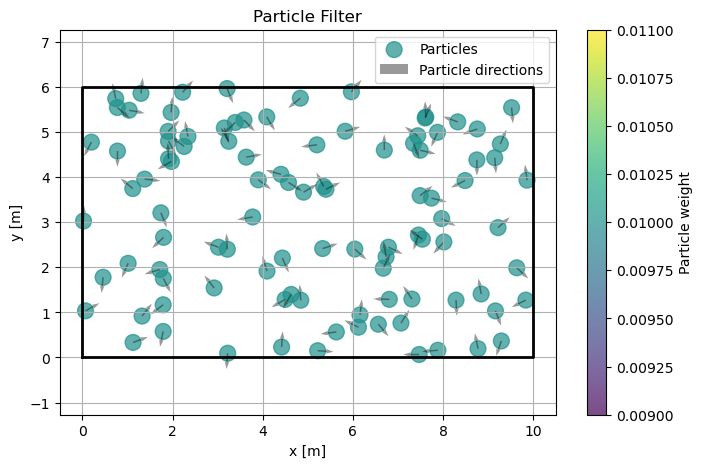

In [5]:
# Test the initialization function and plot
particles, weights = initialize_particles(num_particles=100)
plot_particles(particles, weights)

## Update particles' pose base on control motion

We have a simple robot model, which can linearly go forward and rotate.

To simplify the problem, assume that during the time $dt$, robot will go forward first, then rotate

In [6]:
def motion_update(particles, control, dt=0.1):
    """
    Update particle positions and orientations using a simple velocity motion model.

    particles:
        NumPy array with shape (N, 3)
        Each particle is [x, y, theta]

    control:
        [v, omega]
        v     = linear velocity [m/s]
        omega = angular velocity [rad/s]

    dt:
        Time step [s]

    """
    v, omega = control

    # Current particle orientations
    theta = particles[:, 2]

    # Update position: move forward along current heading
    particles[:, 0] += v * dt * np.cos(theta)
    particles[:, 1] += v * dt * np.sin(theta)

    # Update orientation
    particles[:, 2] += omega * dt

    # Wrap to [-pi pi]
    particles[:, 2] = wrap_angle(particles[:, 2])

    return particles

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


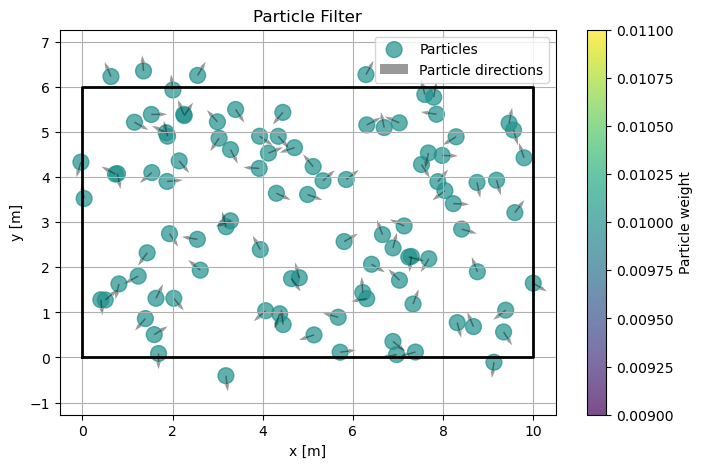

In [7]:
# Test motion update
control = [0.5, 0.2]  # v = 0.5 m/s, omega = 0.2 rad/s
dt = 1  

particles = motion_update(
    particles,
    control,
    dt
)
plot_particles(particles, weights)

## Update the weights based on sensor reading

We have a sensor giving information `z_front`, which is distance to the wall in front of the robot.

We will update the weights of each particles based on the sensor reading `z_front`, and the predicted/estimated distance from each particle to the wall.

Assume that, the error between sensor value and predicted/estimated value is a zero mean Gaussian distribution, we will update the weights based on the probability density function:
$$
w = w * p(x)
$$
$$
p(x) =
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right)
$$

where:

- $x$ is error between sensor reading and estimated value
- $\mu$ is the mean value, which is 0
- $\sigma$ is the standard deviation, which is 0.25 in this example


In [8]:
def sensor_update_front_wall(particles, weights, z_front, sigma=0.25):
    """
    Update particle weights using the error betwee the measurement and estimated value about
    the distance to the wall in front of the robot.
    """

    for i, particle in enumerate(particles):

        # Predicted measurement for this particle
        z_hat = distance_to_front_wall(particle)

        # Measurement error
        error = z_front - z_hat

        # Gaussian likelihood: p(z | x)
        likelihood = norm.pdf(error, loc=0, scale=sigma)

        # Update log weight
        weights[i] *= likelihood

    # Normalize safely
    weights /= np.sum(weights)

    return weights

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


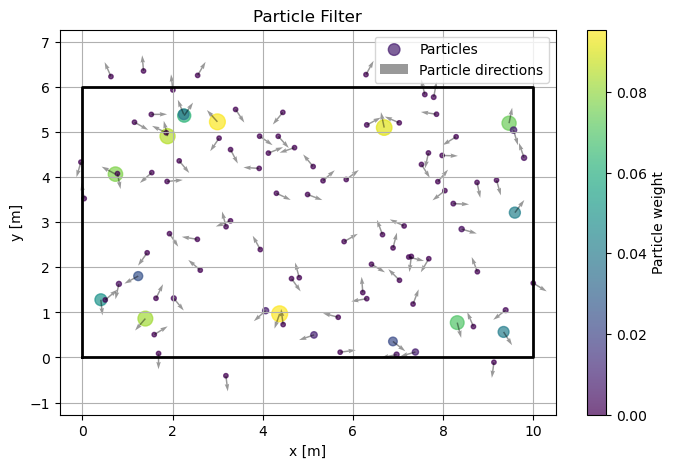

In [9]:
weights = sensor_update_front_wall(particles, weights, 1)
plot_particles(particles, weights)

## Resampling

After the sensor update, each particle has a weight.

A high weight means the particle agrees well with the sensor measurement.  
A low weight means the particle does not agree well with the sensor measurement.

Resampling keeps particles according to their weights:

- high-weight particles are copied more often
- low-weight particles may disappear

After resampling, all particles are given equal weight again.

The belief is then represented by the number of particles in each region.

So, if many particles are concentrated in one area, that area has high probability.

In [10]:
def systematic_resample(particles, weights):
    """
    Systematic resampling.

    High-weight particles are more likely to be selected multiple times.
    After resampling, all particles receive equal weights again.
    """
    num_particles = len(particles)

    # Positions are equally spaced points between 0 and 1
    positions = (np.arange(num_particles) + np.random.rand()) / num_particles

    # Cumulative sum of weights
    cumulative_sum = np.cumsum(weights)

    # Make sure the last value is exactly 1.0
    cumulative_sum[-1] = 1.0

    # Find which particles correspond to the sampled positions
    indices = np.searchsorted(cumulative_sum, positions)

    # Copy selected particles
    particles_resampled = particles[indices].copy()

    # Reset weights to equal values
    weights_resampled = np.ones(num_particles) / num_particles

    return particles_resampled, weights_resampled


## Write the whole pipeline

Given the sensor reading and controls signal below, write the whole pipeline for the particle filter using above function

In [11]:
dt = 0.1
num_particles = 200

controls = [
    np.array([5,  0.00]),   # Step 1
    np.array([5,  0.40]),   # Step 2
    np.array([5,  0.00]),   # Step 3
    np.array([4,  0.00]),   # Step 4
    np.array([4, -0.30]),   # Step 5
    np.array([5,  0.00]),   # Step 6
    np.array([5,  0.30]),   # Step 7
    np.array([4,  0.00]),   # Step 8
    np.array([4,  0.00]),   # Step 9
    np.array([3, -0.20]),   # Step 10
]

sensor_readings = [
    6.50,
    6.15,
    5.75,
    5.40,
    4.80,
    4.35,
    4.05,
    3.80,
    3.50,
    3.20,
]



Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


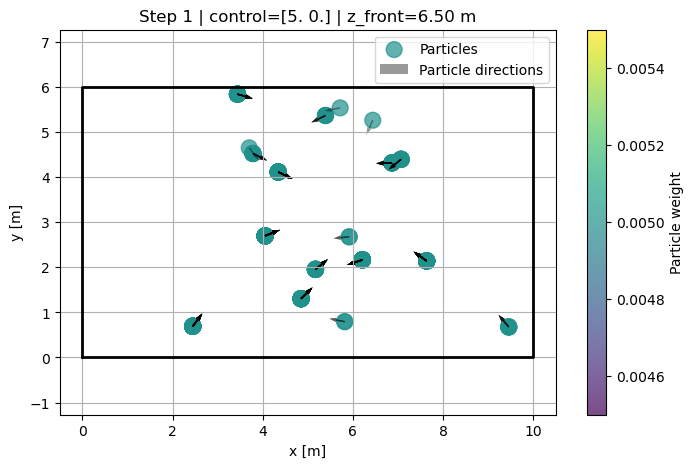

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


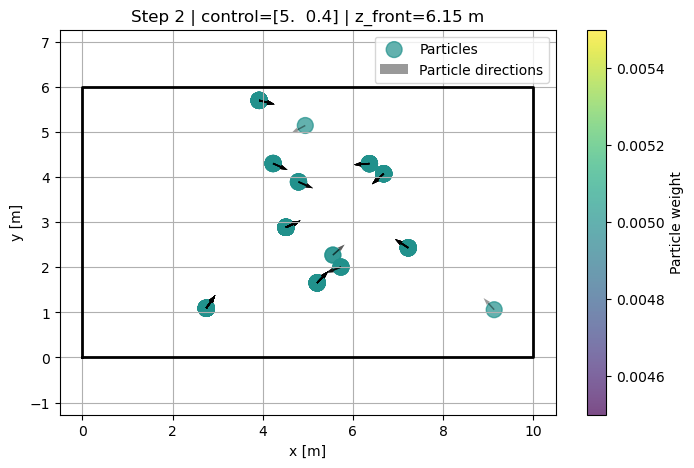

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


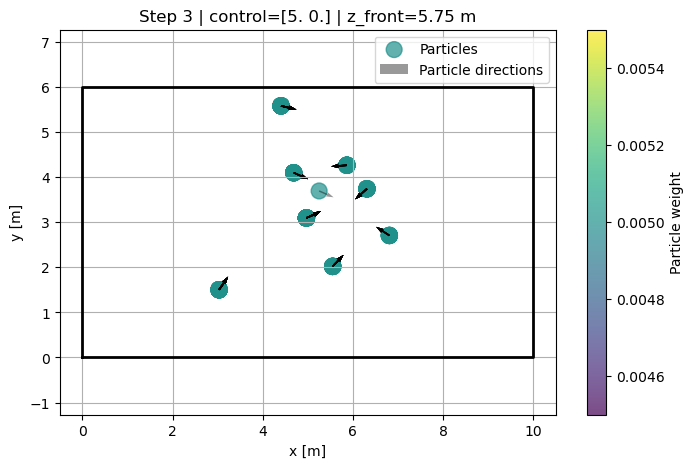

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


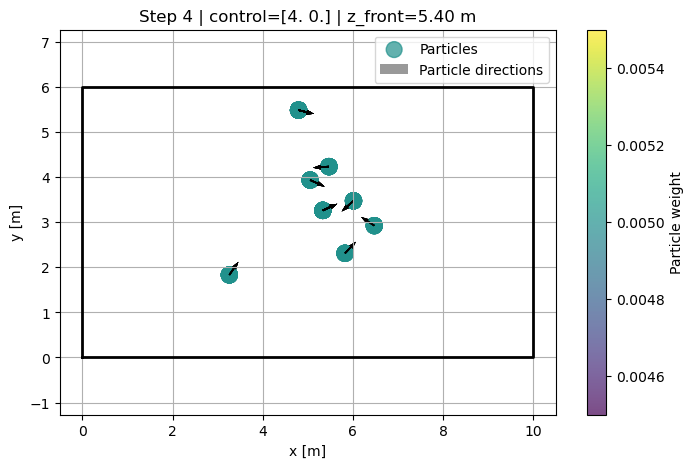

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


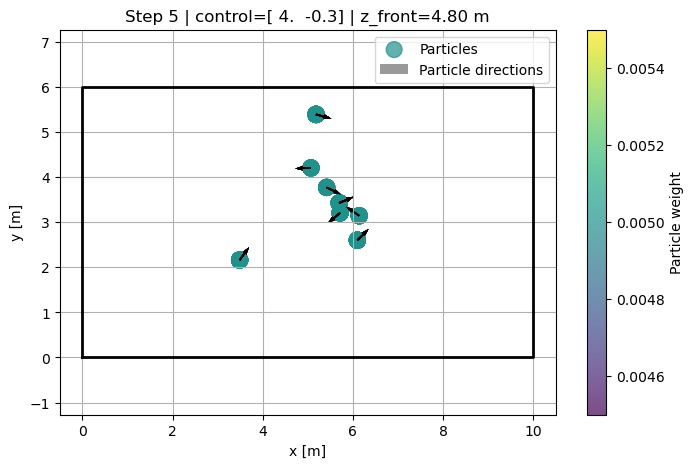

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


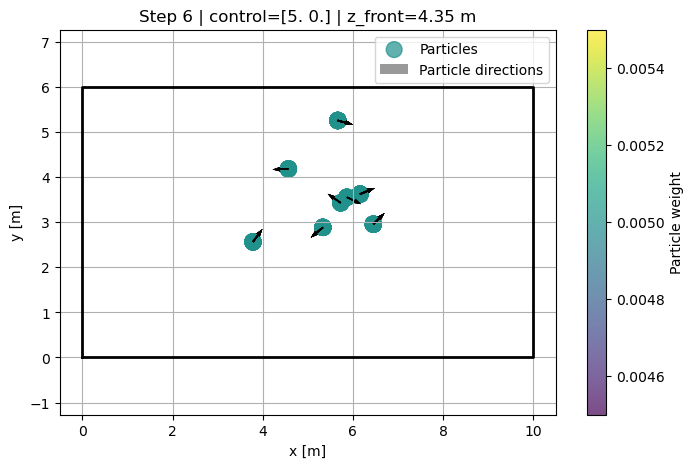

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


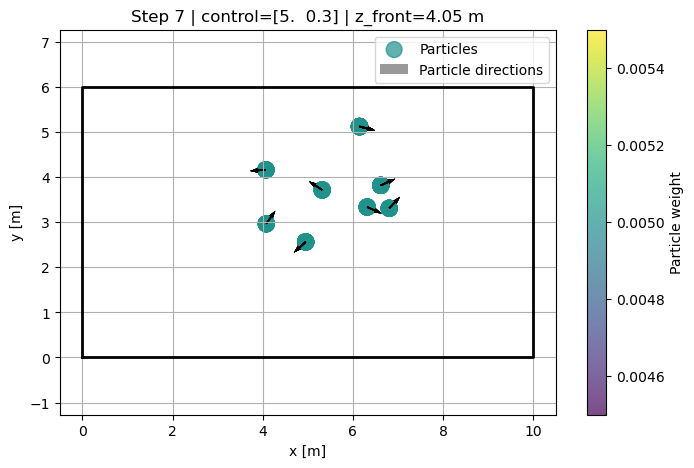

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


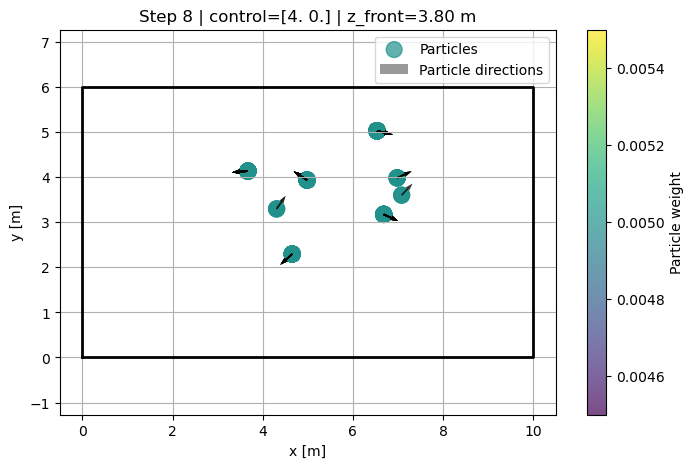

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


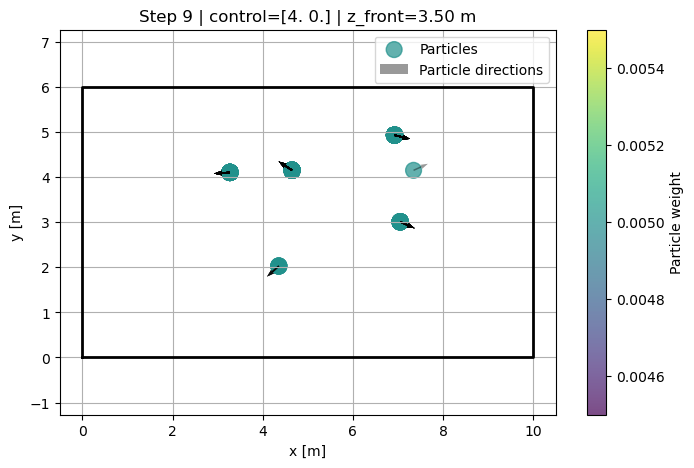

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


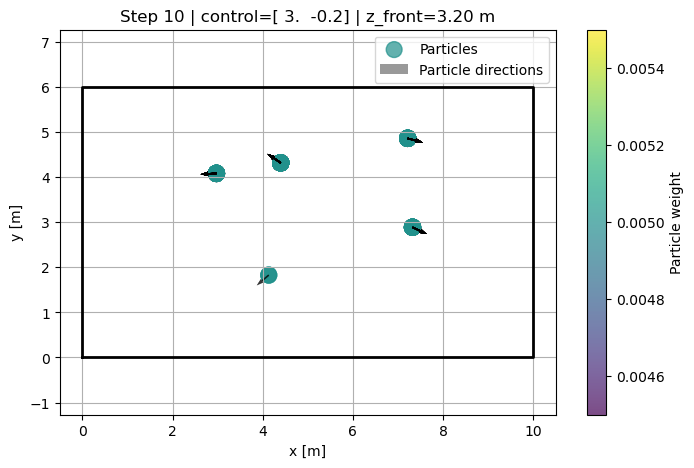

In [12]:
# Full particle filter pipeline
particles, weights = initialize_particles(num_particles)

for step, (control, z_front) in enumerate(zip(controls, sensor_readings)):

    # 1. Predict: move particles according to motion model
    particles = motion_update(particles, control, dt)

    # 2. Update: re-weight particles based on sensor reading
    weights = sensor_update_front_wall(particles, weights, z_front)

    # 3. Resample: draw new particles proportional to weights
    particles, weights = systematic_resample(particles, weights)

    # Visualize each step
    plot_particles(particles, weights, title=f"Step {step + 1} | control={control} | z_front={z_front:.2f} m")